In [109]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
import json
warnings.filterwarnings('ignore')

In [110]:
df = pd.read_csv('dataset/titanic.csv')

# EDA

In [111]:
df = df.drop('PassengerId', axis=1)
df = df.drop('Name',axis=1)
df = df.drop('Cabin',axis=1)
df = df.drop('Ticket',axis=1)


df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  418 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 26.3+ KB


In [113]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,0.416268,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.493530,0.841838,14.181209,0.896760,0.981429,55.907576
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [114]:
df.shape

(418, 8)

In [115]:
df.drop_duplicates(inplace=True) 

In [116]:
print(df.shape)
print("--------------------")
print(df.isnull().sum())
print("--------------------")
print(df.isna().sum())


(385, 8)
--------------------
Survived     0
Pclass       0
Sex          0
Age         62
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64
--------------------
Survived     0
Pclass       0
Sex          0
Age         62
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64


In [117]:
print(df['Embarked'].value_counts())
print("---------------------------")
print(df['Embarked'].isnull().sum())

Embarked
S    252
C     98
Q     35
Name: count, dtype: int64
---------------------------
0


In [118]:
print(df['Sex'].value_counts())
print("---------------------------")
print(df['Sex'].isnull().sum())

Sex
male      239
female    146
Name: count, dtype: int64
---------------------------
0


In [119]:
print(df['Age'].value_counts())
print("---------------------------")
print(df['Age'].isnull().sum())

Age
21.0    17
22.0    16
24.0    16
30.0    14
18.0    13
        ..
76.0     1
28.5     1
22.5     1
62.0     1
38.5     1
Name: count, Length: 79, dtype: int64
---------------------------
62


In [120]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


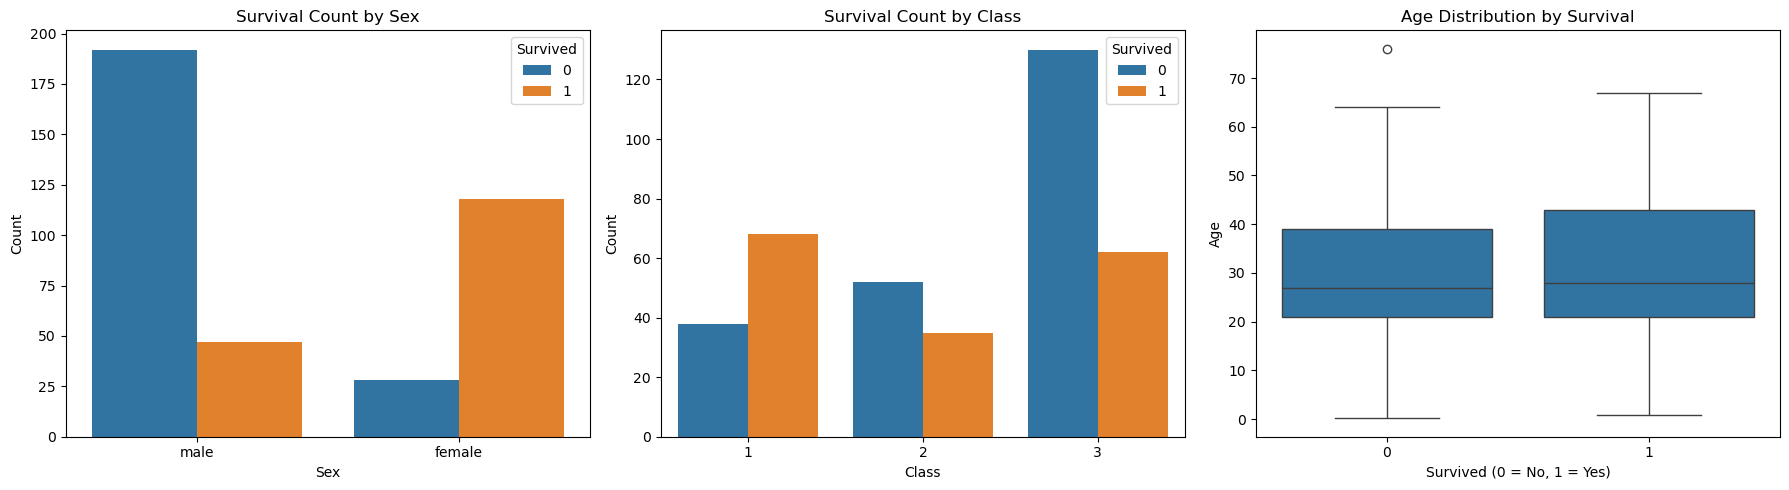

In [121]:
# Create the layout
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# 1. Added [0] to axes
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0])
axes[0].set_title("Survival Count by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

# 2. Added [1] to axes
sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Survival Count by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

# 3. Added [2] to axes
sns.boxplot(data=df, x="Survived", y="Age", ax=axes[2])
axes[2].set_title("Age Distribution by Survival")
axes[2].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[2].set_ylabel("Age")

plt.tight_layout()
plt.show()

In [122]:
df.nunique()

Survived      2
Pclass        3
Sex           2
Age          79
SibSp         7
Parch         8
Fare        169
Embarked      3
dtype: int64

<Axes: >

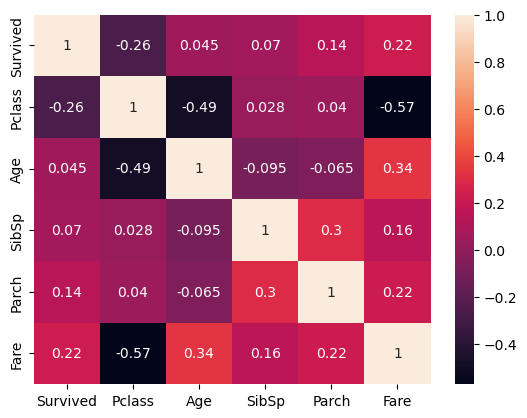

In [123]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# data cleaning and preprocession wiht feature engineering

In [124]:
df_cleaned = df.copy()

In [125]:
df_cleaned.corr(numeric_only=True)["Survived"].sort_values()

Pclass     -0.264339
Age         0.045379
SibSp       0.069847
Parch       0.143402
Fare        0.224815
Survived    1.000000
Name: Survived, dtype: float64

In [126]:
print(df['Sex'].value_counts())
print(df['Survived'].value_counts())

Sex
male      239
female    146
Name: count, dtype: int64
Survived
0    220
1    165
Name: count, dtype: int64


In [127]:
y = df_cleaned['Survived']

In [128]:
X = df_cleaned.drop(columns=['Survived'],axis=1)

In [129]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Numerical Features
num_features = ['Age', 'Fare']

# Categorical Features
cat_features = ['Pclass', 'Sex', 'Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_features)
    ],
    remainder="drop"
)

In [130]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((308, 7), (77, 7))

In [131]:
mean_age = X_train.groupby(["Pclass", "Sex"])["Age"].mean()

X_train["Age"] = X_train.apply(
    lambda row: mean_age[(row["Pclass"], row["Sex"])]
    if pd.isna(row["Age"])
    else row["Age"],
    axis=1
)

X_test["Age"] = X_test.apply(
    lambda row: mean_age.get(
        (row["Pclass"], row["Sex"]),
        X_train["Age"].mean()
    )
    if pd.isna(row["Age"])
    else row["Age"],
    axis=1
)

In [132]:
# print("Train NaN:")
# print(X_train.isnull().sum())

# print("Test NaN:")
# print(X_test.isnull().sum())

train_index = X_train["Fare"].notna()
X_train = X_train[train_index]
y_train = y_train[train_index] 

train_index = X_test["Fare"].notna()
X_test = X_test[train_index]
y_test = y_test[train_index] 

In [133]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [134]:
X.shape

(385, 7)

In [135]:
# Model selection

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ( RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ( accuracy_score, precision_score, recall_score,f1_score)
import joblib
from config import CLASSIFICATION_PARAMS
from sklearn.model_selection import RandomizedSearchCV

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ),
    "CatBoost": CatBoostClassifier(
        verbose=False,
        random_state=42
    )
}

In [137]:
def save_results(results, file_name="titanic_result.json"):
    with open(file_name, "w") as file:
        json.dump(results, file, indent=4)

In [138]:
def tune_model(model_name, model, X_train, y_train):
    if model_name not in CLASSIFICATION_PARAMS:
        return model
        
    print(f"Tuning {model_name}...")
    
    random_search = RandomizedSearchCV( 
        estimator=model, 
        param_distributions=CLASSIFICATION_PARAMS[model_name], 
        n_iter=20, cv=5, 
        scoring="r2", 
        random_state=42, 
        n_jobs=-1)
    
    random_search.fit(X_train, y_train)
    print("Best Parameters :", random_search.best_params_)
    print("Best CV Score :", random_search.best_score_)
    return random_search.best_estimator_

In [139]:
def train_models(models, X_train, X_test, y_train, y_test):

    results = {}
    best_model = None
    best_model_name = ""
    best_score = -1

    for name, model in models.items():

        print(f"\nTraining {name}...")
        # Cross Validation
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="accuracy"
        )

        # Hyperparameter Tuning
        model = tune_model(name, model, X_train, y_train)
        # Train Model
        model.fit(X_train, y_train)

        # Prediction
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        # Train Metrics
        train_accuracy = accuracy_score(y_train, train_pred)
        train_precision = precision_score(y_train, train_pred, average="binary", zero_division=0)
        train_recall = recall_score(y_train, train_pred, average="binary", zero_division=0)
        train_f1 = f1_score(y_train, train_pred, average="binary", zero_division=0)

        # Test Metrics
        test_accuracy = accuracy_score(y_test, test_pred)
        test_precision = precision_score(y_test, test_pred, average="binary", zero_division=0)
        test_recall = recall_score(y_test, test_pred, average="binary", zero_division=0)
        test_f1 = f1_score(y_test, test_pred, average="binary", zero_division=0)

        # Save Best Model
        if test_accuracy > best_score:
            best_score = test_accuracy
            best_model = model
            best_model_name = name

        results[name] = {
            "Cross Validation Accuracy": round(np.mean(cv_scores), 4),

            "train": {
                "Accuracy": round(train_accuracy, 4),
                "Precision": round(train_precision, 4),
                "Recall": round(train_recall, 4),
                "F1 Score": round(train_f1, 4)
            },

            "test": {
                "Accuracy": round(test_accuracy, 4),
                "Precision": round(test_precision, 4),
                "Recall": round(test_recall, 4),
                "F1 Score": round(test_f1, 4)
            }
        }

    print("=" * 60)
    print("Best Model :", best_model_name)
    print("Best Test Accuracy :", round(best_score, 4))
    print("=" * 60)

    joblib.dump(best_model, "model.pkl")

    return results, best_model

In [140]:
results, best_model = train_models(models, X_train, X_test, y_train,  y_test)
save_results(results)


Training Logistic Regression...
Tuning Logistic Regression...
Best Parameters : {'C': 1}
Best CV Score : 0.2211920323685029

Training K-Neighbors Classifier...
Tuning K-Neighbors Classifier...
Best Parameters : {'weights': 'uniform', 'n_neighbors': 5}
Best CV Score : 0.1414285714285714

Training Decision Tree...
Tuning Decision Tree...
Best Parameters : {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'criterion': 'gini'}
Best CV Score : 0.14162153750389045

Training Random Forest...
Tuning Random Forest...
Best Parameters : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best CV Score : 0.20710862122626833

Training Extra Trees...

Training AdaBoost...
Tuning AdaBoost...
Best Parameters : {'n_estimators': 50, 'learning_rate': 0.01}
Best CV Score : 0.2344817927170868

Training Gradient Boosting...
Tuning Gradient Boosting...
Best Parameters : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best 

In [141]:
import joblib

joblib.dump(best_model,"titanic.pkl")

['titanic.pkl']

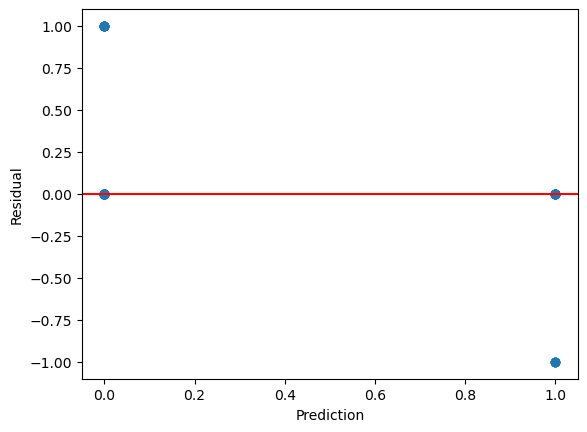

In [142]:
prediction = best_model.predict(X_test)
residual = y_test - prediction
plt.scatter(prediction,residual)
plt.axhline(y=0,color='red')
plt.xlabel("Prediction")
plt.ylabel("Residual")
plt.show()

In [145]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": prediction
})

comparison_df["Difference"] = comparison_df["Actual Price"] - comparison_df["Predicted Price"]

comparison_df["Absolute Error"] = comparison_df["Difference"].abs()

comparison_df["Percentage Error"] = (
    comparison_df["Absolute Error"] / comparison_df["Actual Price"]
) * 100

comparison_df = comparison_df.round(2)

comparison_df.head(20)

,Actual Price,Predicted Price,Difference,Absolute Error,Percentage Error
0,1,1,0,0,0.0
1,1,1,0,0,0.0
2,1,1,0,0,0.0
3,1,1,0,0,0.0
4,0,0,0,0,NaN
5,0,0,0,0,NaN
6,0,0,0,0,NaN
7,1,1,0,0,0.0
8,1,0,1,1,100.0
9,0,0,0,0,NaN
